# py-URD — Tutorial on Guo et al. 2010 fixture

## 1. What this package does

`pyurd` is a port of URD (Farrell et al. *Science* 2018) — branching trajectory inference for scRNA-seq via flood-based pseudotime + biased random walks.

**Citation**: Farrell, J. A. et al. *Single-cell reconstruction of developmental trajectories during zebrafish embryogenesis.* Science 360, eaar3131 (2018).

## 2. Install + import

In [1]:
import sys
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_traj_dev/py-URD')
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_traj_dev/py-destiny')
import pyurd, pydestiny
import numpy as np, pandas as pd, matplotlib.pyplot as plt
print(f'pyurd {pyurd.__version__}, pydestiny {pydestiny.__version__}')

pyurd 0.1.0, pydestiny 0.1.0


## 3. Load Guo data

In [2]:
expr = pd.read_csv('/scratch/users/steorra/analysis/omicverse_traj_dev/py-URD/data/fixture_guo_expression.csv', index_col=0).to_numpy(dtype=np.float64)
print(f'expression shape: {expr.shape}')
cell_names = [f'cell_{i}' for i in range(expr.shape[0])]

expression shape: (428, 48)


## 4. End-to-end pipeline

### 4.1 Diffusion map → transition matrix

In [3]:
dm = pydestiny.DiffusionMap.fit(expr, sigma='local', n_eigs=5, k=20)
print(f'eigenvalues:  {dm.eigenvalues.round(3)}')

eigenvalues:  [0.988 0.973 0.925 0.919 0.882]


### 4.2 URD object

In [4]:
urd = pyurd.URD(cell_names=cell_names, transitions=dm.transitions,
                dm_eigenvectors=dm.eigenvectors, dm_eigenvalues=dm.eigenvalues)
print(f'URD: {urd.n_cells} cells')

URD: 428 cells


### 4.3 Flood pseudotime

pseudotime non-NA: 428/428


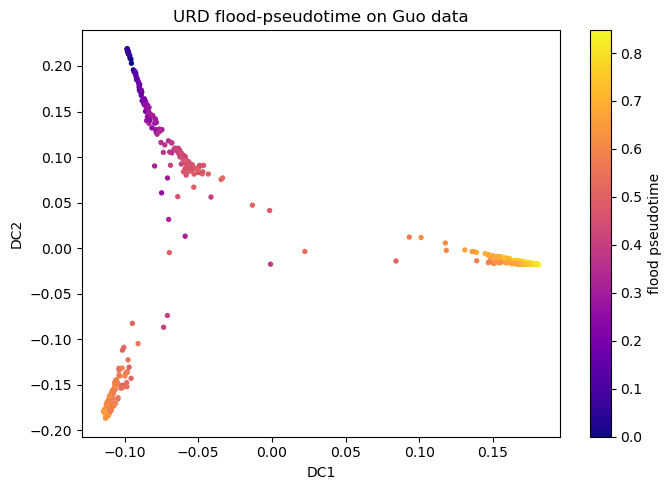

In [5]:
floods = pyurd.floodPseudotime(urd, root_cells=list(range(16)), n=50,
                                minimum_cells_flooded=1, seed=42)
res = pyurd.floodPseudotimeProcess(floods, max_frac_NA=0.9, stability_div=5)
pt = res['pseudotime']
print(f'pseudotime non-NA: {pt.notna().sum()}/{urd.n_cells}')
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(dm.eigenvectors[:,0], dm.eigenvectors[:,1], c=pt.reindex(cell_names).values, s=8, cmap='plasma')
plt.colorbar(sc, label='flood pseudotime')
ax.set_xlabel('DC1'); ax.set_ylabel('DC2')
ax.set_title('URD flood-pseudotime on Guo data')
plt.tight_layout(); plt.show()

### 4.4 Stability diagnostic

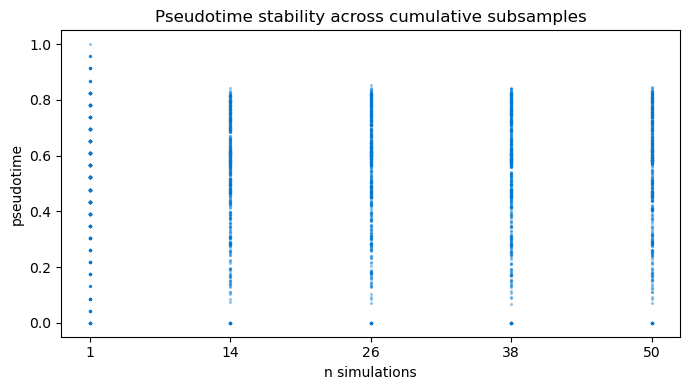

In [6]:
stab = res['pseudotime_stability']
fig, ax = plt.subplots(figsize=(7, 4))
for col in stab.columns:
    ax.scatter([col]*len(stab), stab[col], s=2, alpha=0.3, color='#0078d4')
ax.set_xlabel('n simulations'); ax.set_ylabel('pseudotime')
ax.set_title('Pseudotime stability across cumulative subsamples')
plt.tight_layout(); plt.show()

### 4.5 Biased random walks from tips

visit_freq shape: (428, 2)


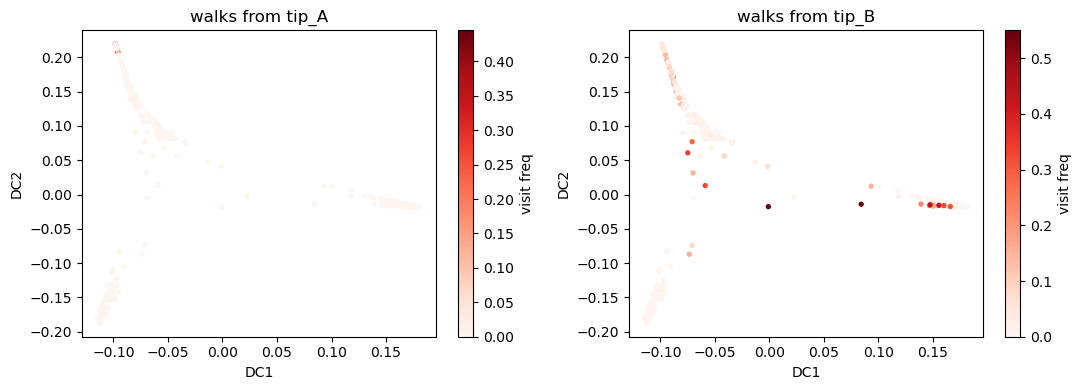

In [7]:
tip_cells = {'tip_A': [0, 1, 2], 'tip_B': [425, 426, 427]}
walks = pyurd.simulateRandomWalksFromTips(urd, pseudotime=pt.reindex(cell_names),
                                           tip_cells=tip_cells, n_per_tip=200,
                                           max_steps=500, seed=42)
visit_freq = pyurd.processRandomWalks(walks)
print(f'visit_freq shape: {visit_freq.shape}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tip in zip(axes, ['tip_A', 'tip_B']):
    sc = ax.scatter(dm.eigenvectors[:,0], dm.eigenvectors[:,1], c=visit_freq[tip].values, s=8, cmap='Reds')
    plt.colorbar(sc, ax=ax, label='visit freq')
    ax.set_title(f'walks from {tip}')
    ax.set_xlabel('DC1'); ax.set_ylabel('DC2')
plt.tight_layout(); plt.show()

## 5. Common pitfalls
- **Root cells**: pick a *cluster* of root cells, not a single one. Single roots stall at `minimum_cells_flooded` quickly.
- **`minimum_cells_flooded=1`**: needed for small/qPCR datasets where transition probabilities are low.
- **Pseudotime stability**: should plateau across the right side of the stability plot; if not, increase `n` simulations.